In [24]:
import mudata as md
import scanpy as sc
from scipy.spatial.distance import cdist

# Load data into a Muon object.
# mdata = md.read_h5mu(r"D:\Scunpair_Project\Dataset\data_repro\bmcite.h5mu.gz")
mdata = md.read_h5mu(r"D:\Scunpair_Project\Dataset\data_repro\OP_Cite.h5mu.gz")

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\mudata\_core\mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [33]:
rna = mdata['rna'].copy()
adt = mdata['adt'].copy()

In [23]:
rna.obs['Site']

GCATTAGCATAAGCGG-1-s1d1    site1
TACAGGTGTTAGAGTA-1-s1d1    site1
AGGATCTAGGTCTACT-1-s1d1    site1
GTAGAAAGTGACACAG-1-s1d1    site1
TCCGAAAAGGATCATA-1-s1d1    site1
                           ...  
GAATCACCACGGAAGT-1-s4d9    site4
GCTGGGTGTACGGATG-1-s4d9    site4
TCGAAGTGTGACAGGT-1-s4d9    site4
GCAGGCTGTTGCATAC-1-s4d9    site4
ACGTAACAGGTCTACT-1-s4d9    site4
Name: Site, Length: 90260, dtype: category
Categories (4, object): ['site1', 'site2', 'site3', 'site4']

In [30]:
rna = rna[rna.obs['Site']=='site1'].copy()
adt = adt[adt.obs['Site']=='site1'].copy()

In [28]:
sc.pp.highly_variable_genes(rna, flavor='seurat_v3', n_top_genes=2000, subset=True)
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.pp.pca(rna)
sc.pp.neighbors(rna)
sc.tl.umap(rna)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


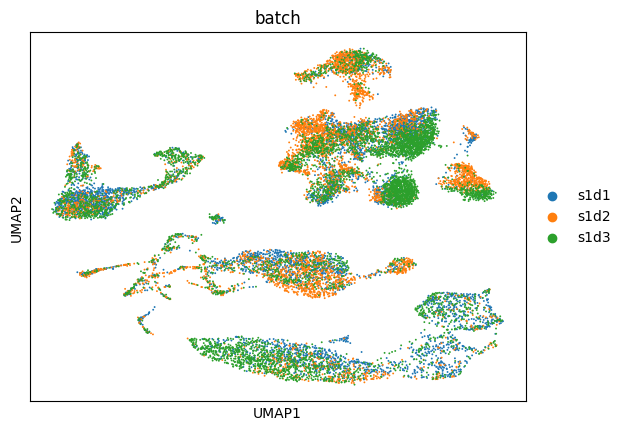

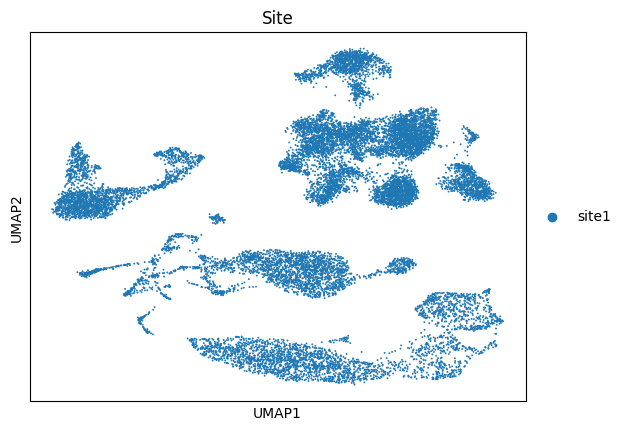

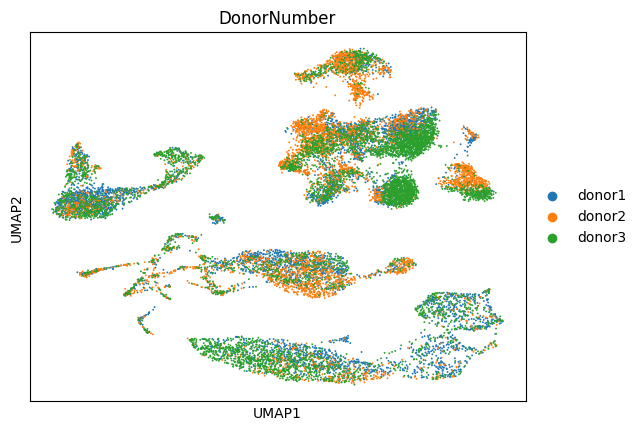

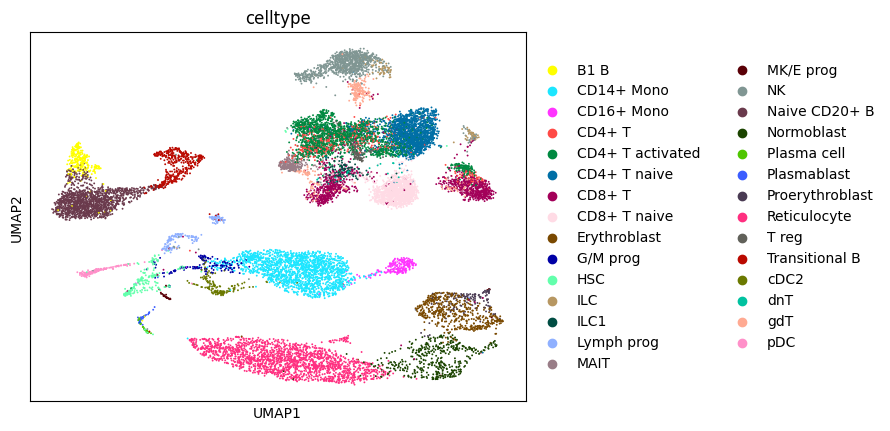

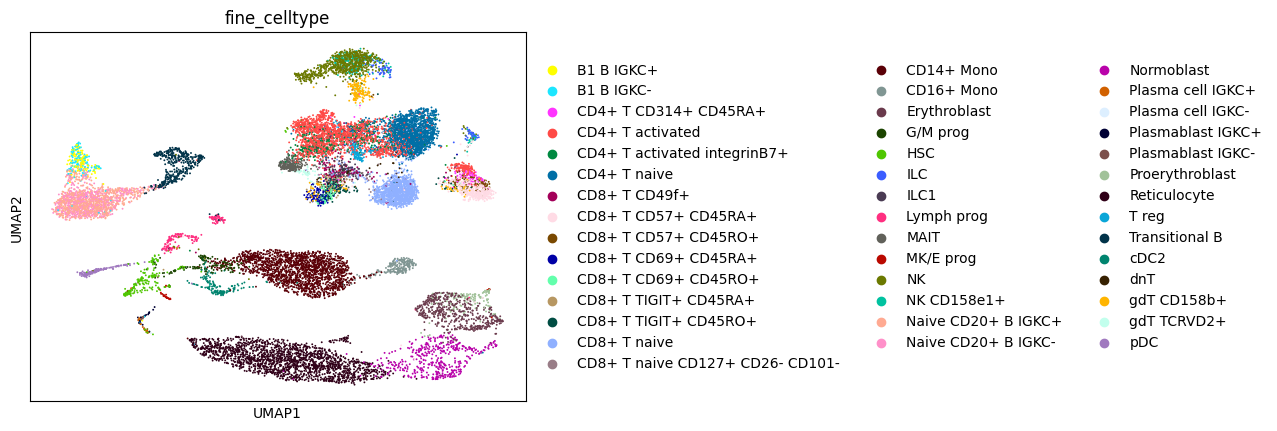

In [29]:
# sc.pl.umap(rna, color=['celltype.l1', 'celltype'])
sc.pl.umap(rna, color=['batch'])
sc.pl.umap(rna, color=['Site'])
sc.pl.umap(rna, color=['DonorNumber'])
sc.pl.umap(rna, color=['celltype'])
sc.pl.umap(rna, color=['fine_celltype'])

In [34]:
sc.pp.normalize_total(adt)
sc.pp.log1p(adt)
# mycode.utils.clr(adt)
sc.pp.scale(adt,max_value=10)
sc.pp.pca(adt)
sc.pp.neighbors(adt)
sc.tl.umap(adt)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


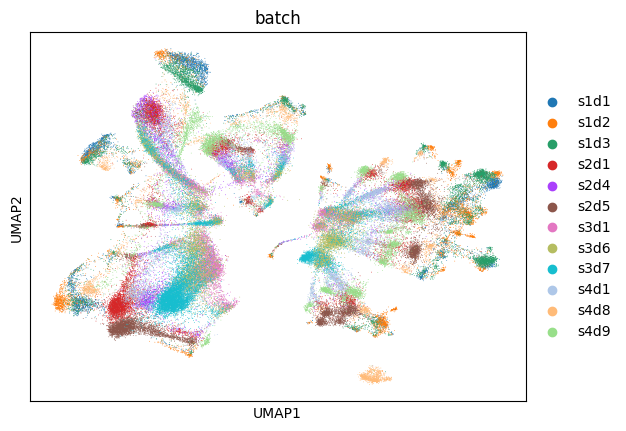

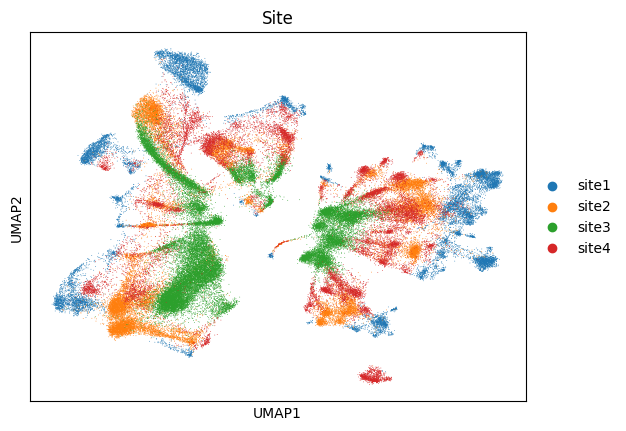

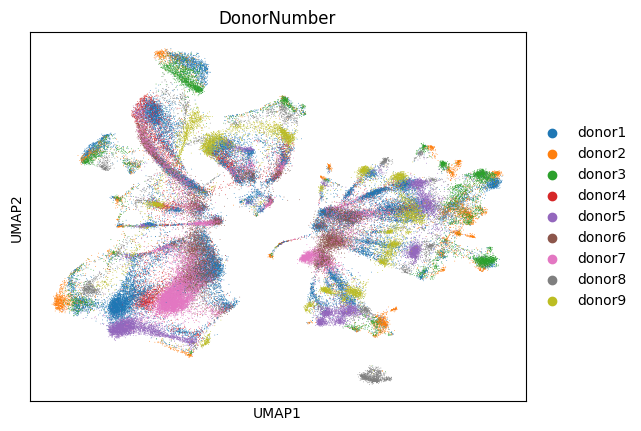

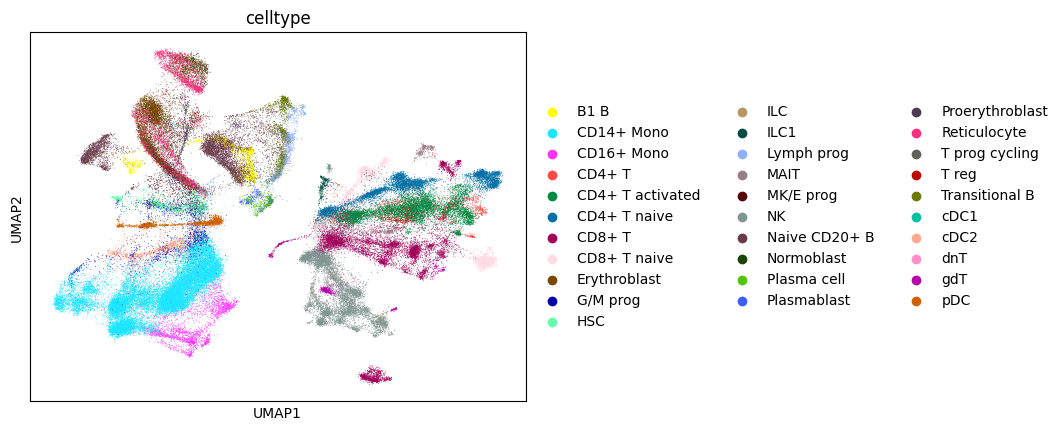

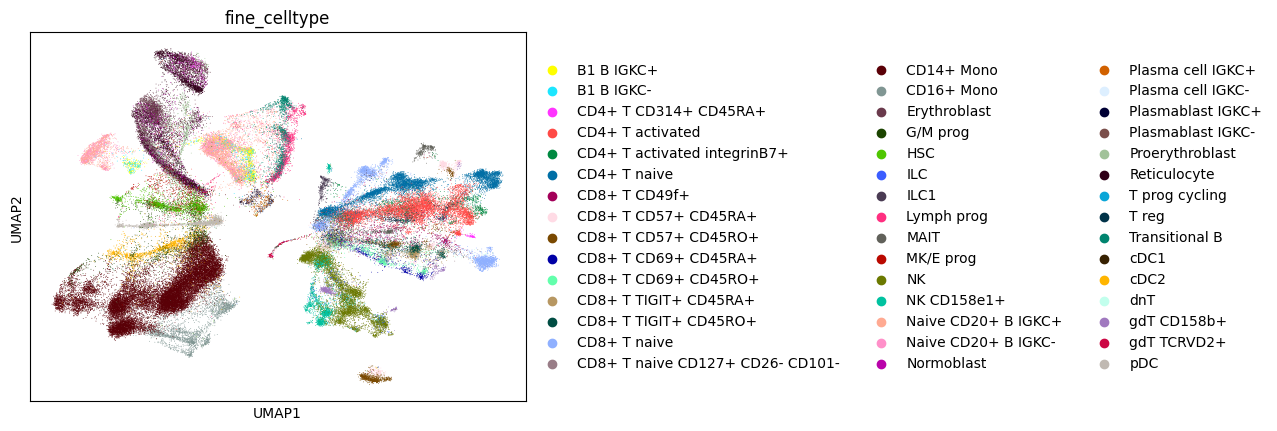

In [35]:
# sc.pl.umap(adt, color=['celltype.l1', 'celltype'])
sc.pl.umap(adt, color=['batch'])
sc.pl.umap(adt, color=['Site'])
sc.pl.umap(adt, color=['DonorNumber'])
sc.pl.umap(adt, color=['celltype'])
sc.pl.umap(adt, color=['fine_celltype'])